In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# Cargar datos
import pandas as pd

train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")

# Normalizar etiquetas (True/False → 1/0)

label_map = {"False": 0, "True": 1}
train_df["Category"] = train_df["Category"].astype(str).str.strip().str.capitalize().map(label_map)
test_df["Category"] = test_df["Category"].astype(str).str.strip().str.capitalize().map(label_map)

# Separar train/test

X_train = train_df["Headline_Text"].astype(str).tolist()
y_train = train_df["Category"].tolist()

X_test = test_df["Headline_Text"].astype(str).tolist()
y_test = test_df["Category"].tolist()


In [ ]:
# Tokenización
#tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-bne")
tokenizer = AutoTokenizer.from_pretrained("bertin-project/bertin-roberta-base-spanish")
train_encodings = tokenizer(X_train, truncation=True, padding="max_length", max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding="max_length", max_length=128)

In [ ]:
# Tensores
train_dataset = TensorDataset(
    torch.tensor(train_encodings["input_ids"]),
    torch.tensor(train_encodings["attention_mask"]),
    torch.tensor(y_train)
)
test_dataset = TensorDataset(
    torch.tensor(test_encodings["input_ids"]),
    torch.tensor(test_encodings["attention_mask"]),
    torch.tensor(y_test)
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
# Modelo
#model = AutoModelForSequenceClassification.from_pretrained("PlanTL-GOB-ES/roberta-base-bne", num_labels=2)
model = AutoModelForSequenceClassification.from_pretrained(
    "bertin-project/bertin-roberta-base-spanish",
    num_labels=2
)

# Optimizador
optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Calcular pesos de clase según distribución en train_df
import torch.nn as nn
class_counts = train_df["Category"].value_counts()
total = len(train_df)
weights = [total/class_counts[0], total/class_counts[1]]
weights = torch.tensor(weights, dtype=torch.float).to(device)

# Definir función de pérdida con pesos
loss_fn = nn.CrossEntropyLoss(weight=weights)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Entrenamiento con early stopping
from tqdm import tqdm
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

patience = 4
best_f1 = 0.0
counter = 0

for epoch in range(15):  # base de 15 epochs
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())
    print(f"Epoch {epoch+1} completado!!!")

    # Evaluación rápida en validación/test para early stopping
    model.eval()
    preds, labels_eval = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_eval.extend(labels.cpu().numpy())

    f1 = f1_score(labels_eval, preds, average="macro")
    print(f"Epoch {epoch+1} - F1 en validación: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), "best_model_roberta.pt")
        print("Mejora detectada, guardando modelo temporal...")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping activado: no hay mejora en F1.")
            break


Epoch 1: 100%|██████████| 170/170 [00:59<00:00,  2.87it/s, loss=0.306]


Epoch 1 completado!!!
Epoch 1 - F1 en validación: 0.7672
Mejora detectada, guardando modelo temporal...


Epoch 2: 100%|██████████| 170/170 [01:00<00:00,  2.83it/s, loss=0.162]


Epoch 2 completado!!!
Epoch 2 - F1 en validación: 0.8095
Mejora detectada, guardando modelo temporal...


Epoch 3: 100%|██████████| 170/170 [01:00<00:00,  2.80it/s, loss=0.565]


...

Epoch 13 completado!!!
Epoch 13 - F1 en validación: 0.8397


Epoch 14: 100%|██████████| 170/170 [01:02<00:00,  2.73it/s, loss=0.000549]


Epoch 14 completado!!!
Epoch 14 - F1 en validación: 0.8643


Epoch 15: 100%|██████████| 170/170 [01:02<00:00,  2.73it/s, loss=0.000188]


Epoch 15 completado!!!
Epoch 15 - F1 en validación: 0.8292


In [ ]:
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

model.eval()
preds, true_labels, probs = [], [], []
with torch.no_grad():
    loop = tqdm(test_loader, leave=True, desc="Evaluando")
    for batch in loop:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        prob_true = torch.softmax(logits, dim=-1)[:,1]
        probs.extend(prob_true.cpu().numpy())
print()
print("Matriz de confusión:\n", confusion_matrix(true_labels, preds))
print("Exactitud (Accuracy):", accuracy_score(true_labels, preds))
print("\nReporte de clasificación:\n", classification_report(true_labels, preds, target_names=["False","True"], digits=4))

roc_auc_base = roc_auc_score(true_labels, probs)
print(f"ROC-AUC: {roc_auc_base:.4f}")


Evaluando: 100%|██████████| 43/43 [00:04<00:00,  8.74it/s]


Matriz de confusión:
 [[531  22]
 [ 43  82]]
Exactitud (Accuracy): 0.9041297935103245

Reporte de clasificación:
               precision    recall  f1-score   support

       False     0.9251    0.9602    0.9423       553
        True     0.7885    0.6560    0.7162       125

    accuracy                         0.9041       678
   macro avg     0.8568    0.8081    0.8292       678
weighted avg     0.8999    0.9041    0.9006       678

ROC-AUC: 0.9584


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

model.eval()
probs, true_labels = [], []
with torch.no_grad():
    loop = tqdm(test_loader, leave=True, desc="Calculando probabilidades")
    for batch in loop:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)[:,1]
        probs.extend(probabilities.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

probs = np.array(probs)
true_labels = np.array(true_labels)

# Curva Precision-Recall y umbral óptimo
precision, recall, thresholds = precision_recall_curve(true_labels, probs)
f1_scores = [f1_score(true_labels, (probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Umbral óptimo: {best_threshold:.3f} con F1={f1_scores[best_idx]:.4f}")

# Evaluar con umbral ajustado
adjusted_preds = (probs >= best_threshold).astype(int)

print("Matriz de confusión (umbral ajustado):\n", confusion_matrix(true_labels, adjusted_preds))
print("Exactitud (Accuracy, umbral ajustado):", accuracy_score(true_labels, adjusted_preds))
print("\nReporte de clasificación (umbral ajustado):\n", classification_report(true_labels, adjusted_preds, target_names=["False","True"], digits=4))

roc_auc_adjusted = roc_auc_score(true_labels, probs)
print(f"ROC-AUC (umbral ajustado): {roc_auc_adjusted:.4f}")


Calculando probabilidades: 100%|██████████| 43/43 [00:04<00:00,  8.77it/s]


Umbral óptimo: 0.003 con F1=0.7985
Matriz de confusión (umbral ajustado):
 [[514  39]
 [ 16 109]]
Exactitud (Accuracy, umbral ajustado): 0.9188790560471977

Reporte de clasificación (umbral ajustado):
               precision    recall  f1-score   support

       False     0.9698    0.9295    0.9492       553
        True     0.7365    0.8720    0.7985       125

    accuracy                         0.9189       678
   macro avg     0.8531    0.9007    0.8739       678
weighted avg     0.9268    0.9189    0.9214       678

ROC-AUC (umbral ajustado): 0.9584


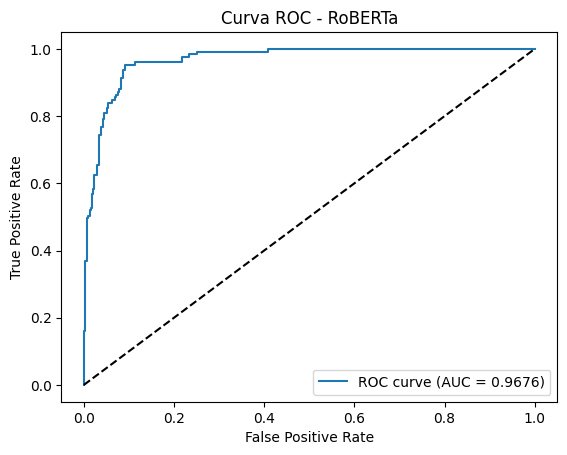

In [ ]:
# Curva ROC al final
fpr, tpr, _ = roc_curve(true_labels, probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_base:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - RoBERTa")
plt.legend(loc="lower right")
plt.savefig("curva_roc_roberta.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Cargar el mejor checkpoint
model.load_state_dict(torch.load("best_model_roberta.pt"))

# Guardar modelo y tokenizer
model.save_pretrained("modelo_roberta_final")
tokenizer.save_pretrained("modelo_roberta_final")

# Comprimir la carpeta en un ZIP
!zip -r modelo_roberta_final.zip modelo_roberta_final

# Descargar el archivo ZIP a tu PC (desde Colab)
from google.colab import files
files.download("modelo_roberta_final.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

updating: modelo_roberta_final/ (stored 0%)
updating: modelo_roberta_final/tokenizer.json (deflated 82%)
updating: modelo_roberta_final/model.safetensors (deflated 8%)
updating: modelo_roberta_final/config.json (deflated 51%)
updating: modelo_roberta_final/tokenizer_config.json (deflated 52%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#para descomprimir modelo ya entrenado
!unzip modelo_roberta_final.zip -d ./modelo_roberta_final


In [ ]:
#cargar modelo y tokenizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("./modelo_roberta_final")
tokenizer = AutoTokenizer.from_pretrained("./modelo_roberta_final")
